✅ Đã import thành công các module từ 'src'!
⏳ Đang tải dữ liệu từ: c:\GitProjects\air_quality_timeseries-lab4\data\raw\PRSA2017_Data_20130301-20170228.zip...
⏳ Đang trích xuất chuỗi thời gian cho trạm: Aotizhongxin...
✅ Dữ liệu sẵn sàng! Train: 33648 giờ, Test: 1416 giờ.


c:\GitProjects\air_quality_timeseries-lab4\src\timeseries_library.py:55: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  s = s.resample(cfg.freq).mean()


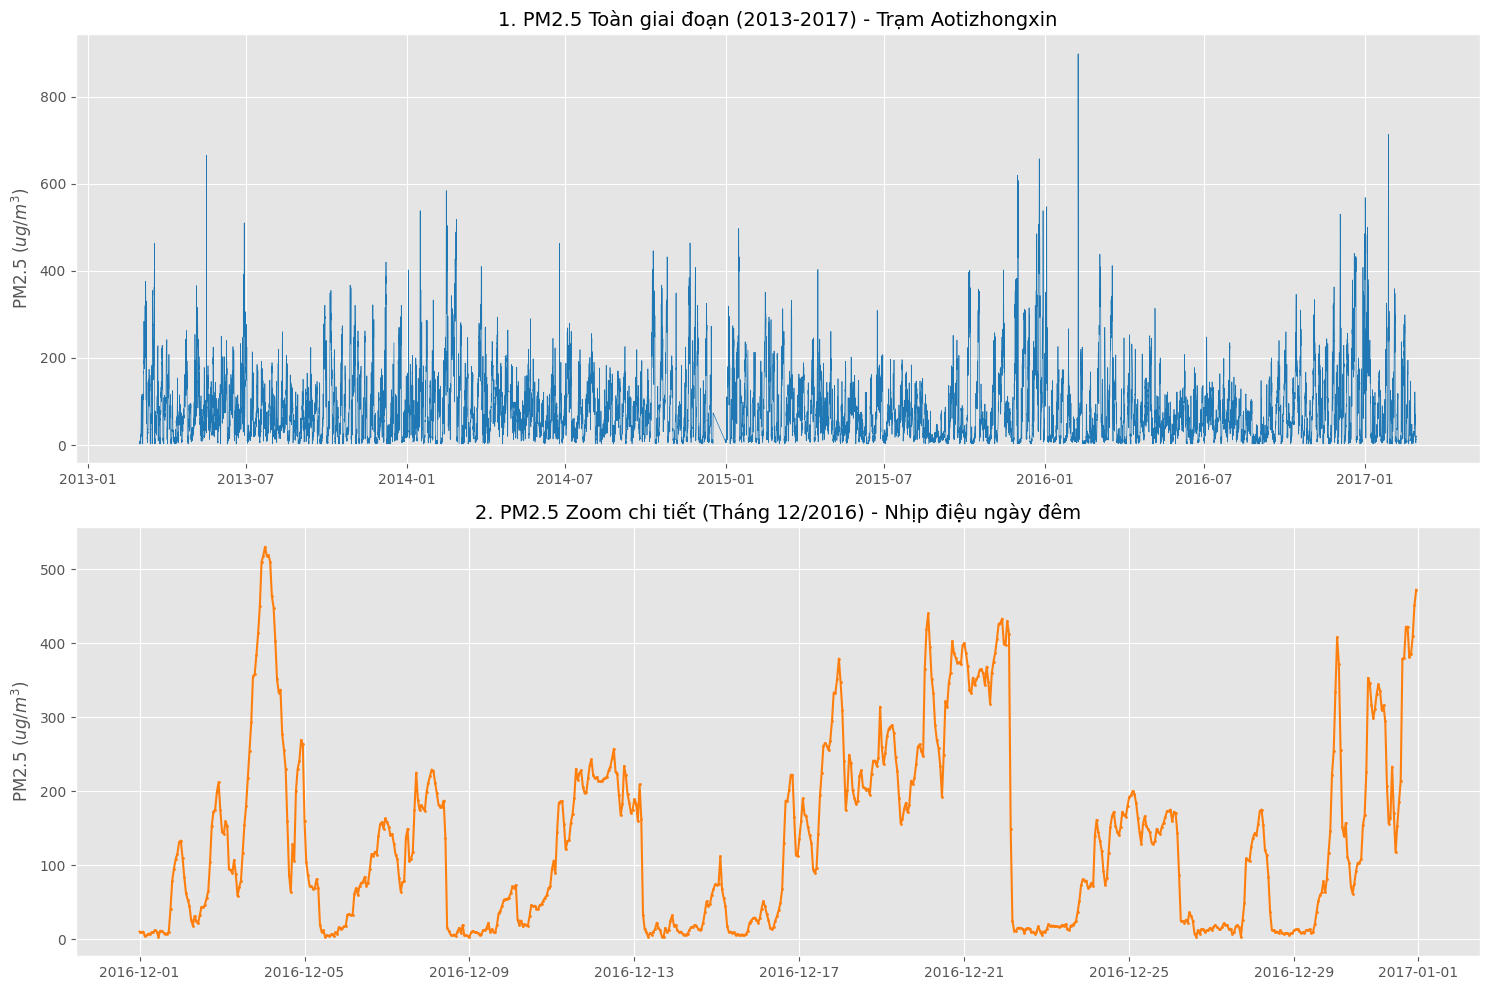

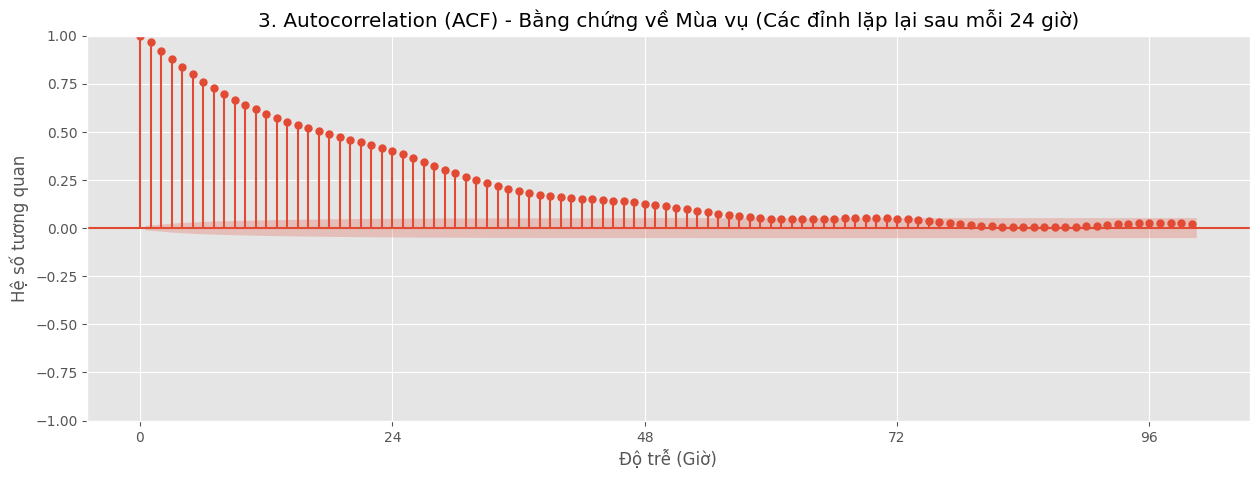


⏳ Đang huấn luyện mô hình SARIMA (1, 0, 1)x(0, 1, 1, 24)...
⚠️ Lưu ý: Quá trình này có thể mất 1-2 phút do mô hình phức tạp...
✅ Huấn luyện xong! AIC: 19009.16
⏳ Đang dự báo 48 giờ tiếp theo...
----------------------------------------
KẾT QUẢ ĐÁNH GIÁ (Horizon = 48 giờ)
RMSE: 140.7515
MAE : 118.0834
----------------------------------------


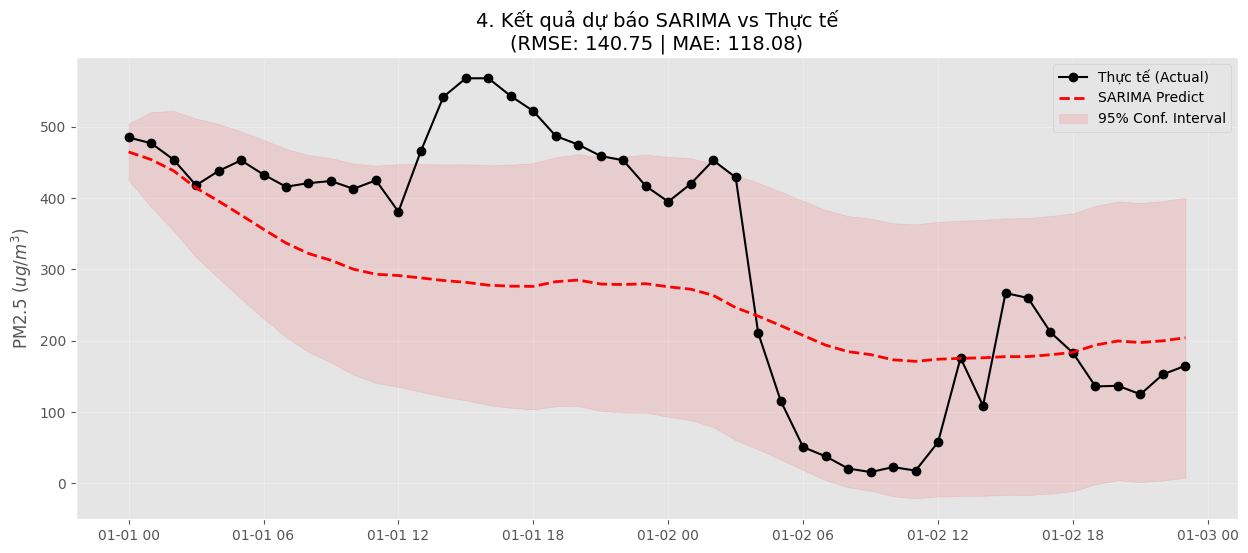

In [ ]:
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. CẤU HÌNH ĐƯỜNG DẪN (QUAN TRỌNG ĐỂ KHÔNG BỊ LỖI IMPORT) ---
current_dir = Path.cwd()
project_root = None

# Logic tìm thư mục gốc:
if (current_dir / 'src').exists():
    project_root = current_dir
elif (current_dir.parent / 'src').exists():
    project_root = current_dir.parent
elif (current_dir.parent.parent / 'src').exists():
    project_root = current_dir.parent.parent
else:
    # Nếu không tìm thấy, giả định đang ở root (trường hợp chạy script)
    project_root = current_dir

# Thêm vào sys.path
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# --- 2. IMPORT THƯ VIỆN & MODULE DỰ ÁN ---
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

try:
    from src.classification_library import load_beijing_air_quality, clean_air_quality_df
    from src.timeseries_library import StationSeriesConfig, make_hourly_station_series, train_test_split_series
    print("✅ Đã import thành công các module từ 'src'!")
except ImportError as e:
    print("\n❌ LỖI: Không tìm thấy thư mục 'src'.")
    print(f"Python đang tìm tại: {sys.path}")
    print("Vui lòng đảm bảo file notebook này nằm trong cấu trúc thư mục của dự án (ví dụ: trong folder 'notebooks').")
    raise e

# --- 3. CẤU HÌNH THAM SỐ (PARAMETERS) ---
STATION = 'Aotizhongxin'       # Trạm cần dự báo
CUTOFF = '2017-01-01'          # Mốc chia Train/Test
HORIZON_HOURS = 48             # Dự báo bao nhiêu giờ tương lai?

# Tìm đường dẫn file dữ liệu
zip_path_candidates = [
    project_root / 'data/raw/PRSA2017_Data_20130301-20170228.zip',
    project_root / 'data/raw/PRSA2017_Data_20130301-20170228.zip',
    'data/raw/PRSA2017_Data_20130301-20170228.zip'
]
RAW_ZIP_PATH = next((str(p) for p in zip_path_candidates if Path(p).exists()), None)

if not RAW_ZIP_PATH:
    raise FileNotFoundError("❌ Không tìm thấy file dữ liệu 'PRSA2017_Data_20130301-20170228.zip' trong thư mục data/raw/")

# --- 4. TẢI VÀ LÀM SẠCH DỮ LIỆU ---
print(f"⏳ Đang tải dữ liệu từ: {RAW_ZIP_PATH}...")
df_raw = load_beijing_air_quality(use_ucimlrepo=False, raw_zip_path=RAW_ZIP_PATH)
df_clean = clean_air_quality_df(df_raw)

print(f"⏳ Đang trích xuất chuỗi thời gian cho trạm: {STATION}...")
cfg = StationSeriesConfig(station=STATION, value_col='PM2.5', freq='H')
s = make_hourly_station_series(df_clean, cfg)

# Chia Train/Test
train, test = train_test_split_series(s, cutoff=CUTOFF)
print(f"✅ Dữ liệu sẵn sàng! Train: {len(train)} giờ, Test: {len(test)} giờ.")

# --- 5. TRỰC QUAN HÓA (YÊU CẦU CỦA ĐỀ BÀI) ---
plt.style.use('ggplot') # Làm đẹp biểu đồ

# === HÌNH 1 & 2: Overview và Zoom ===
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Hình 1: Toàn cảnh
axes[0].plot(s.index, s.values, color='#1f77b4', linewidth=0.5)
axes[0].set_title(f'1. PM2.5 Toàn giai đoạn (2013-2017) - Trạm {STATION}', fontsize=14)
axes[0].set_ylabel('PM2.5 ($ug/m^3$)')

# Hình 2: Zoom 1 tháng
zoom_start = '2016-12-01'
zoom_end = '2016-12-31'
s_zoom = s[zoom_start:zoom_end]
axes[1].plot(s_zoom.index, s_zoom.values, color='#ff7f0e', marker='.', markersize=2)
axes[1].set_title(f'2. PM2.5 Zoom chi tiết (Tháng 12/2016) - Nhịp điệu ngày đêm', fontsize=14)
axes[1].set_ylabel('PM2.5 ($ug/m^3$)')

plt.tight_layout()
plt.show()

# === HÌNH 3: Chứng minh mùa vụ (ACF Plot) ===
plt.figure(figsize=(15, 5))
plot_acf(train.dropna(), lags=100, ax=plt.gca(), alpha=0.05, 
         title=f'3. Autocorrelation (ACF) - Bằng chứng về Mùa vụ (Các đỉnh lặp lại sau mỗi 24 giờ)')
plt.xticks(np.arange(0, 101, 24)) # Đánh dấu chu kỳ 24, 48, 72...
plt.xlabel('Độ trễ (Giờ)')
plt.ylabel('Hệ số tương quan')
plt.show()

# --- 6. HUẤN LUYỆN SARIMA ---
my_order = (1, 0, 1) 
my_seasonal_order = (0, 1, 1, 24)

print(f"\n⏳ Đang huấn luyện mô hình SARIMA {my_order}x{my_seasonal_order}...")
print("⚠️ Lưu ý: Quá trình này có thể mất 1-2 phút do mô hình phức tạp...")

train_sample = train.iloc[-24*90:] 

model = ARIMA(train_sample, order=my_order, seasonal_order=my_seasonal_order)
model_fit = model.fit()

print(f"✅ Huấn luyện xong! AIC: {model_fit.aic:.2f}")

print(f"⏳ Đang dự báo {HORIZON_HOURS} giờ tiếp theo...")
forecast_res = model_fit.get_forecast(steps=HORIZON_HOURS)
y_pred = forecast_res.predicted_mean
y_true = test.iloc[:HORIZON_HOURS]
conf_int = forecast_res.conf_int()

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print("-" * 40)
print(f"KẾT QUẢ ĐÁNH GIÁ (Horizon = {HORIZON_HOURS} giờ)")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print("-" * 40)

plt.figure(figsize=(15, 6))
plt.plot(y_true.index, y_true.values, label='Thực tế (Actual)', color='black', marker='o')
plt.plot(y_pred.index, y_pred.values, label=f'SARIMA Predict', color='red', linestyle='--', linewidth=2)

plt.fill_between(y_pred.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='red', alpha=0.1, label='95% Conf. Interval')

plt.title(f'4. Kết quả dự báo SARIMA vs Thực tế\n(RMSE: {rmse:.2f} | MAE: {mae:.2f})', fontsize=14)
plt.legend()
plt.ylabel('PM2.5 ($ug/m^3$)')
plt.grid(True, alpha=0.3)
plt.show()